# NAE optimization
This file sees how far we can push pyAQSC's aspect ratio

In [ ]:
import importlib
import aqsc
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

from jax import flatten_util, jit, jacfwd
from functools import partial
from jax.lax import while_loop

In [2]:
# import desc
# from desc import set_device
# from desc.grid import LinearGrid
# set_device("gpu")

In [3]:
# Constants and resolution
static_freq = 100 # low-pass filter freq
traced_freq = 40 # low-pass filter freq
len_phi = 100 # number of phi sample points
phis_2pi = jnp.linspace(0,2*jnp.pi, len_phi, endpoint=False)
R0_fixed = 1.0 # fixed major radius
RZ_clip = 0.2 # fixing min and max R and Z coeffs to prevent crazy axes
nfp = 2

In [4]:
def spec_weight(n):
    return jnp.e**(-jnp.arange(n))

In [5]:
jnp.e**(-jnp.arange(8))

Array([1.00000000e+00, 3.67879441e-01, 1.35335283e-01, 4.97870684e-02,
       1.83156389e-02, 6.73794700e-03, 2.47875218e-03, 9.11881966e-04],      dtype=float64)

In [6]:
Rc = jnp.array([1.,   0.1,   0., 0., 0., 0., 0., 0.])
Zs = jnp.array([0.,   0.1,   0., 0., 0., 0., 0., 0.])
pc = jnp.array([0.05, 0.005, 0., 0., 0., 0., 0., 0.])
Rc_raw = Rc/spec_weight(len(Rc))
Zs_raw = Zs/spec_weight(len(Zs))
pc_raw = pc/spec_weight(len(pc))

In [7]:
# Initial cond
init_dict = {
    'Rc_raw': Rc_raw,
    'Zs_raw': Zs_raw,
    # 'Rc': qa_Rc,
    # 'Zs': qa_Zs,
    'pc_raw': pc_raw,
    'Delta_0_avg': 0.,
    'B_theta_20_avg': 0.,
    'B_alpha_1': 0.1,
    'B0': 1.0,
    'B11c': -1.8,
    'B22c': 0.,
    'B20': 0., 
    'B22s': 0.,
    'B_alpha_nb2_34': 0.,
    'B_alpha_nb2_56': 0.,
    'B_denom_3': [0., 0.], # 0., 0.], # B33s, B31s, B31c, B33c
    'B_denom_4': [0.,], # 0., 0., 0., 0.], # B33s, B31s, B31c, B33c
    'B_denom_5': [0., 0.,], # 0., 0., 0., 0.], # B33s, B31s, B31c, B33c
    'B_denom_6': [0.,], # 0., 0., 0., 0., 0., 0.], # B33s, B31s, B31c, B33c
}

# init_dict_QA = {
#     'Rc': qa_Rc,
#     'Zs': qa_Zs,
#     'pc': [0., 0., 0., 0., 0., 0., 0., 0.0],
#     'Delta_0_avg': 0.,
#     'B_theta_20_avg': 0.,
#     'B_alpha_1': 0.,
#     'B0': 0.,
#     'B11c': 0.,
#     'B22c': 0.,
#     'B20': 0., 
#     'B22s': 0.,
#     'B_alpha_nb2_34': 0.,
#     'B_alpha_nb2_56': 0.,
# }

x_flat_init, unravel_x = flatten_util.ravel_pytree(init_dict)

In [8]:
@partial(jit, static_argnames='padded')
def solve_order_6(x_flat, m=10, padded=True):
    in_dict = unravel_x(x_flat)
    # Rc = in_dict['Rc'].at[0].set(R0_fixed)
    m_list = jnp.arange(len(in_dict['Rc_raw']))
    Rc_raw = in_dict['Rc_raw']
    Zs_raw = in_dict['Zs_raw']
    pc_raw = in_dict['pc_raw']
    
    
    Rc_raw = jnp.where(m_list<=m, Rc_raw, 0)
    Zs_raw = jnp.where(m_list<=m, Zs_raw, 0)
    pc_raw = jnp.where(m_list<=m, pc_raw, 0)

    # Clipping the fourier coefficients
    # to prevent crazy axis
    Rc_raw = jnp.clip(Rc_raw, -RZ_clip, RZ_clip)
    Zs_raw = jnp.clip(Zs_raw, -RZ_clip, RZ_clip)

    if padded:
        chiphifunc_type = aqsc.ChiPhiFuncPadded
    else:
        chiphifunc_type = aqsc.ChiPhiFunc
    
    # Weighting
    # Pressure
    weight_pc = spec_weight(len(pc_raw))
    pc = pc_raw * weight_pc
    # R and Z
    weight_RZ = spec_weight(len(Rc_raw))
    Rc = list(Rc_raw * weight_RZ)
    Zs = list(Zs_raw * weight_RZ)
    # Fixing major radius
    Rc[0] = R0_fixed
    # Stellsym axis
    Rs = [0] * len(Rc)
    Zc = [0] * len(Zs)

    Delta_0_avg = in_dict['Delta_0_avg']
    B_theta_20_avg = in_dict['B_theta_20_avg']
    B_alpha_1 = in_dict['B_alpha_1']
    B0 = in_dict['B0']
    B11c = in_dict['B11c']
    B22c = in_dict['B22c']
    B20 = in_dict['B20']
    B22s = in_dict['B22s']
    B_alpha_nb2_34 = in_dict['B_alpha_nb2_34']
    B_alpha_nb2_56 = in_dict['B_alpha_nb2_56']
    B_denom_3 = in_dict['B_denom_3']
    B_denom_4 = in_dict['B_denom_4']
    B_denom_5 = in_dict['B_denom_5']
    B_denom_6 = in_dict['B_denom_6']
    # Reconstructing the p array from cos coeffs
    p_mode_num = jnp.arange(len(pc))*nfp
    p_Phi0 = phis_2pi/nfp
    p_phi_times_mode = p_mode_num[:, None]*p_Phi0[None, :]
    p_cos_arr = jnp.cos(p_phi_times_mode)
    p0 = jnp.sum(pc[:, None]*p_cos_arr, axis=0)
    equilibrium = aqsc.leading_orders(
        nfp=nfp,
        Rc=Rc,
        Rs=Rs,
        Zc=Zc,
        Zs=Zs,
        p0=p0,
        Delta_0_avg=Delta_0_avg,
        B_alpha_1=B_alpha_1,
        B0=B0,
        B11c=B11c,
        B22c=B22c,
        B20=B20,
        B22s=B22s,
        B_theta_20_avg=B_theta_20_avg,
        len_phi=len_phi,
        len_phi_axis=500,
        static_max_freq=(static_freq, static_freq),
        traced_max_freq=(traced_freq, traced_freq),
        tol_riccati=1e-8,
        max_iter_riccati=50,
        n_shooting_riccati=1000,
        padded=padded
    )
    equilibrium = aqsc.iterate_2(
        equilibrium,
        B_denom_nm1 = chiphifunc_type(
            jnp.array(B_denom_3)[:, None],
            equilibrium.nfp,
            trig_mode=True
        ), # B3
        B_denom_n = chiphifunc_type(
            jnp.array(B_denom_4)[:, None],
            equilibrium.nfp,
            trig_mode=True
        ), # B4
        B_alpha_nb2 = B_alpha_nb2_34,
        static_max_freq=(static_freq, static_freq),
        traced_max_freq=(traced_freq, traced_freq),
    )
    equilibrium = aqsc.iterate_2(
        equilibrium,
        B_denom_nm1 = chiphifunc_type(
            jnp.array(B_denom_5)[:, None],
            equilibrium.nfp,
            trig_mode=True
        ), # B5
        B_denom_n = chiphifunc_type(
            jnp.array(B_denom_6)[:, None],
            equilibrium.nfp,
            trig_mode=True
        ), # B6
        B_alpha_nb2 = B_alpha_nb2_56,
        static_max_freq=(static_freq, static_freq),
        traced_max_freq=(traced_freq, traced_freq),
    )
    return equilibrium

In [9]:
%%timeit
eq_test = solve_order_6(x_flat_init, padded=True)

Default interpolation method: cubic
Solving for \bar{\iota}_0 self-consistently.
Evaluating order 3 4
Evaluating order 5 6
277 ms ± 9.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%%timeit
eq_test = solve_order_6(x_flat_init, padded=False)

Default interpolation method: cubic
Solving for \bar{\iota}_0 self-consistently.
Evaluating order 3 4
Evaluating order 5 6
288 ms ± 23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


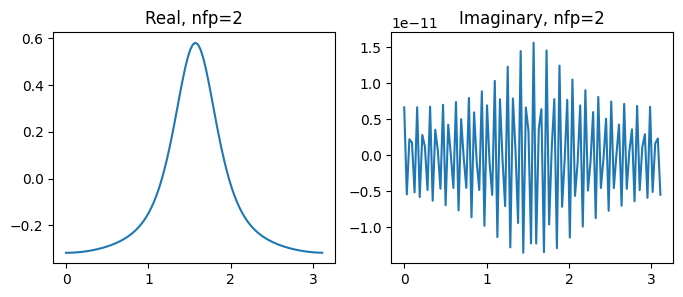

Array(1.84027826, dtype=float64)

In [12]:
eq_test.p_perp[2][0].display_content()
eq_test.p_perp[2][0].get_l2()

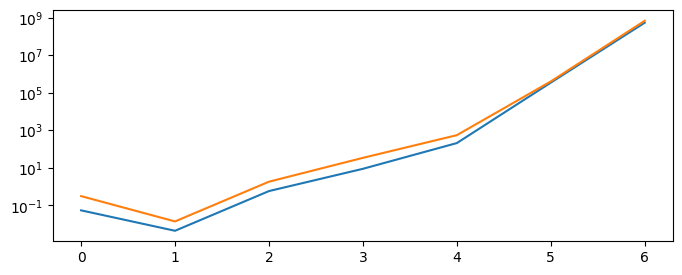

In [13]:
plt.plot(eq_test.p_perp.get_max_order_by_order())
plt.plot(eq_test.p_perp.get_l2_order_by_order())
plt.yscale('log')

In [14]:
def divergence_rate(eq):
    amp_B_psi_coef_cp = eq.unknown['B_psi_coef_cp'].get_l2_order_by_order()
    amp_B_theta_coef_cp = eq.unknown['B_theta_coef_cp'].get_l2_order_by_order()
    amp_Delta_coef_cp = eq.unknown['Delta_coef_cp'].get_l2_order_by_order()
    amp_X_coef_cp = eq.unknown['X_coef_cp'].get_l2_order_by_order()
    amp_Y_coef_cp = eq.unknown['Y_coef_cp'].get_l2_order_by_order()
    amp_Z_coef_cp = eq.unknown['Z_coef_cp'].get_l2_order_by_order()
    amp_p_perp_coef_cp = eq.unknown['p_perp_coef_cp'].get_l2_order_by_order()
    rate_X_coef_cp = amp_X_coef_cp[-2:] / amp_X_coef_cp[-3:-1]
    rate_Y_coef_cp = amp_Y_coef_cp[-2:] / amp_Y_coef_cp[-3:-1]
    rate_Z_coef_cp = amp_Z_coef_cp[-2:] / amp_Z_coef_cp[-3:-1]
    rate_B_psi_coef_cp = amp_B_psi_coef_cp[-2:] / amp_B_psi_coef_cp[-3:-1]
    rate_B_theta_coef_cp = amp_B_theta_coef_cp[-2:] / amp_B_theta_coef_cp[-3:-1]
    rate_Delta_coef_cp = amp_Delta_coef_cp[-2:] / amp_Delta_coef_cp[-3:-1]
    rate_p_perp_coef_cp = amp_p_perp_coef_cp[-2:] / amp_p_perp_coef_cp[-3:-1]
    all_rates = jnp.array([
        rate_X_coef_cp,
        rate_Y_coef_cp,
        rate_Z_coef_cp,
        rate_B_psi_coef_cp,
        rate_B_theta_coef_cp,
        rate_Delta_coef_cp,
        rate_p_perp_coef_cp,
    ])
    return jnp.average(all_rates)

def eps_conv(eq):
    return 1 / divergence_rate(eq)
    

In [22]:
@jit
def p_rms_vol(eq, eps, eps2, n_max=float('inf')):
    vol = eq.volume_eps(eps=eps, n_max=n_max)
    vol2 = eq.volume_eps(eps=eps2, n_max=n_max)
    p2 = eq.p_perp * eq.p_perp
    p2_int = eq.volume_integral(p2, n_max=n_max).eval_eps(eps, 0., 0.)
    p2_int2 = eq.volume_integral(p2, n_max=n_max).eval_eps(eps2, 0., 0.)
    p2_int_shell = p2_int - p2_int2
    vol_shell = vol - vol2
    p_rms = jnp.sqrt(jnp.real(
        p2_int_shell/vol_shell
    ))
    return p_rms

@jit
def vol_conv(eq):
    eps = eps_conv(eq)
    return eq.volume_eps(eps)

@jit
def aspect_conv(eq):
    eps = eps_conv(eq)
    return eq.aspect_ratio_eps(eps)

@jit
def rms_anisotropy(eq):
    eps = eps_conv(eq)
    int_anisotropy = jnp.real(
        eq.volume_integral(eq.Delta*eq.Delta).eval_eps(eps=eps, chi=0, phi=0)
    )
    return jnp.sqrt(int_anisotropy/vol_conv(eq))


@jit
def rms_p(eq):
    eps = eps_conv(eq)
    int_p_perp = jnp.real(
        eq.volume_integral(eq.p_perp*eq.p_perp).eval_eps(eps=eps, chi=0, phi=0)
    )
    return jnp.sqrt(int_p_perp/vol_conv(eq))

@jit 
def iota_axis(eq):
    return jnp.real(eq.iota.eval(psi=0, chi=0, phi=0))

In [16]:

init_anisotropy = rms_anisotropy(eq_test)
init_aspect = aspect_conv(eq_test)
init_eps_conv = eps_conv(eq_test)
init_beta = eq_test.beta_rms(init_eps_conv)
init_p_edge = p_rms_vol(eq_test, 1*init_eps_conv, 0.99*init_eps_conv)
init_p_axis = p_rms_vol(eq_test, 0.01*init_eps_conv, 0*init_eps_conv)
init_p00_avg = jnp.real(jnp.average(eq_test.p_perp[0][0].content))
init_p20_avg = jnp.real(jnp.average(eq_test.p_perp[2][0].content))
print('Initial anisotropy:', init_anisotropy)
print('Initial aspect ratio:', init_aspect)
print('Initial eps conv:', init_eps_conv)
print('Initial iota axis:', iota_axis(eq_test))
print('Initial beta', init_beta)
print('Initial p edge:', init_p_edge)
print('Initial p axis:', init_p_axis)
print('Initial p00 avg:', init_p00_avg)
print('Initial p20 avg:', init_p20_avg)
print('Initial p00+p20*eps^2:', init_p00_avg + init_p20_avg*init_eps_conv**2)

Initial anisotropy: 0.0035354684874119536
Initial aspect ratio: 955.863845529235
Initial eps conv: 0.0007477441875975214
Initial iota axis: -0.10690900649486905
Initial beta 0.05012484582011123
Initial p edge: 0.05012478026294585
Initial p axis: 0.050124844137083735
Initial p00 avg: 0.05
Initial p20 avg: -0.09893180096693201
Initial p00+p20*eps^2: 0.0499999446851159


In [17]:
target_iota = 0.2
target_anisotropy = 1e-2
target_aspect = 10.
target_beta = 0.05

In [18]:

anisotropy = rms_anisotropy(eq_test)
aspect = aspect_conv(eq_test)
eps = eps_conv(eq_test)
beta_rms = eq_test.beta_rms(eps)
iota_a = jnp.real(eq_test.iota.eval(psi=0, chi=0, phi=0))
iota_b = jnp.real(eq_test.iota.eval(psi=eps**2, chi=0, phi=0))
iota_avg = (iota_a + iota_b)/2

In [19]:
eq_test.B_denom[2][0]

Array(0.+0.j, dtype=complex128)

In [82]:
def objective(x_flat, w_aspect, w_anisotropy, w_iota, w_p, m):
    in_dict = unravel_x(x_flat)
    eq = solve_order_6(x_flat, m)
    anisotropy = rms_anisotropy(eq)
    aspect = aspect_conv(eq)
    eps = eps_conv(eq)

    # Iota
    iota_a = jnp.real(eq.iota.eval(psi=0, chi=0, phi=0))

    # Effective field strength at the edge
    B_denom_20 = jnp.real(in_dict['B20'])
    B_denom_0 = jnp.real(in_dict['B0'])
    B_denom_edge_eff = (B_denom_0 + B_denom_20*eps**2)
    # Effective pressure at the edge
    p20_avg = jnp.real(jnp.average(eq.p_perp[2][0].content))
    p00_avg = jnp.real(jnp.average(eq.p_perp[0][0].content))
    p_edge_eff = (p00_avg + p20_avg*eps**2)
    p_axis_eff = p00_avg
    # # beta_edge eff
    beta_axis_eff = p00_avg*B_denom_0
    beta_edge_eff = p_edge_eff*B_denom_edge_eff
    B2_eff = 1/(B_denom_0 + B_denom_20 * eps**2)
    term1 = w_aspect * (
        jnp.maximum(aspect-target_aspect, 0) / target_aspect
    )**2
    term2 = w_anisotropy * (
        jnp.maximum(anisotropy - target_anisotropy, 0) / target_anisotropy
    )**2
    term3 = w_iota * (
        jnp.maximum(jnp.abs(target_iota) - jnp.abs(iota_a), 0) / target_iota
    )**2
    # term4 = w_p * (
    #     jnp.maximum(p20_avg, 0) / p20_avg
    # )**2
    term4 = w_p * (
        jnp.maximum(beta_edge_eff - beta_axis_eff, 0) / beta_axis_eff
    )**2
    out = term1 + term2 + term3 + term4
    return out

def obj_wrapped(x_flat, w_aspect, w_anisotropy, w_iota, w_p, m):
    out = objective(x_flat, w_aspect, w_anisotropy, w_iota, w_p, m)
    if np.isfinite(out):
        return out
    else:
        return 1e10

# Global optimization

In [83]:
def _objective_vmap(x, a, b, c, d):
    return jax.vmap(
        lambda x_, a_, b_, c_, d_: objective(x_, a_, b_, c_, d_, 10),
        in_axes=(0, None, None, None, None),
        out_axes=0,
    )(x, a, b, c, d)

objective_vmap = jax.jit(_objective_vmap)

In [84]:
import jax
from evosax.algorithms import CMA_ES

In [87]:
# Instantiate the search strategy
es = CMA_ES(population_size=64, solution=x_flat_init)
params = es.default_params

In [88]:
# Initialize state
key = jax.random.key(0)
state = es.init(key, x_flat_init, params)

In [89]:
key, key_ask, key_eval = jax.random.split(key, 3)
# Generate a set of candidate solutions to evaluate
population, state = es.ask(key_ask, state, params)

In [90]:
w_aspect, w_anisotropy, w_iota, w_p = 6., 0.5, 1., 1.
fitness1 = objective_vmap(population[:16, :], w_aspect, w_anisotropy, w_iota, w_p)

In [91]:
num_generations = 1000
fitness_list = []
i_list = []
time_tot = 0
ask = jit(es.ask)

In [ ]:
import time
import numpy as np

# Ask-Eval-Tell loop
time_init = time.time()
for i in range(num_generations):
    key, key_ask, key_eval = jax.random.split(key, 3)

    # Generate a set of candidate solutions to evaluate
    population, state = ask(key_ask, state, params)

    # Actually fits in memory
    time1 = time.time()
    fitness1 = objective_vmap(population[:16, :]  , w_aspect, w_anisotropy, w_iota, w_p)
    fitness2 = objective_vmap(population[16:32, :], w_aspect, w_anisotropy, w_iota, w_p)
    fitness3 = objective_vmap(population[32:48, :], w_aspect, w_anisotropy, w_iota, w_p)
    fitness4 = objective_vmap(population[48:64, :], w_aspect, w_anisotropy, w_iota, w_p)
    fitness = jnp.concatenate([
        fitness1,
        fitness2,
        fitness3,
        fitness4,
    ], axis=0)
    time2 = time.time()
    if i%10==0:
        fitness_list.append(fitness.copy())
        i_list.append(i)
        print('time', time2-time1)
        print('mean', jnp.nanmin(fitness))
        print('#nan', np.sum(np.isnan(fitness)))
    # Update the evolution strategy
    state, metrics = es.tell(key, population, fitness, state, params)
time_fin = time.time()
time_tot = time_tot + (time_fin - time_init)
print('total time', time_fin - time_init)
# Get best solution

time 4.775850772857666
mean 534459.9095767786
#nan 24
time 4.6140296459198
mean 536856.6727018995
#nan 32


In [95]:
argsort_fitness = np.argsort(fitness)
sorted_fitness = fitness[argsort_fitness]
sorted_population = population[argsort_fitness]

In [71]:
jnp.save('population.npy', population)
jnp.save('fitness.npy', fitness)

In [72]:
# loading
population = jnp.load('population.npy')

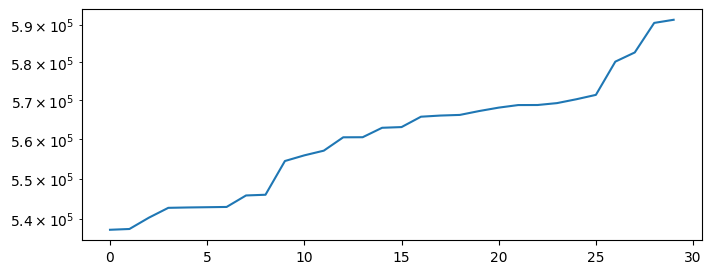

In [96]:
plt.plot(fitness[argsort_fitness])
plt.yscale('log')

In [41]:
objective_vmap(sorted_population[:16])

Array([41399.45252446, 41525.51379673, 41789.64924355, 41912.06532838,
       41987.68592953, 42094.7722986 , 42235.22852864, 43225.70129778,
       43512.96857926, 43703.02312013, 43931.59033407, 44727.72194568,
       44753.85130607, 45132.00918692, 45927.95020529, 45935.71869542],      dtype=float64)

Δ:   5.4835e-04     R/r:   3.0004e+02     ι0:  -4.4448e-02     p_axis-p_edge (estimate):  -1.6594e-06     


/scratch/miniconda3/envs/desc/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/scratch/miniconda3/envs/desc/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Δ:   5.9519e-04     R/r:   3.0681e+02     ι0:  -3.9682e-02     p_axis-p_edge (estimate):  -1.8128e-06     
Δ:   6.5582e-04     R/r:   3.0863e+02     ι0:  -4.8262e-02     p_axis-p_edge (estimate):  -1.8564e-06     
Δ:   7.7104e-04     R/r:   3.1203e+02     ι0:  -3.9021e-02     p_axis-p_edge (estimate):  -2.0469e-06     
Δ:   6.8673e-04     R/r:   3.0990e+02     ι0:  -3.9322e-02     p_axis-p_edge (estimate):  -1.5296e-06     
Δ:   5.0689e-04     R/r:   3.1921e+02     ι0:  -4.2875e-02     p_axis-p_edge (estimate):  -1.7058e-06     
Δ:   5.5771e-04     R/r:   3.0236e+02     ι0:  -4.6997e-02     p_axis-p_edge (estimate):  -1.7261e-06     
Δ:   5.7191e-04     R/r:   3.2763e+02     ι0:  -3.9767e-02     p_axis-p_edge (estimate):  -1.6766e-06     
Δ:   5.7616e-04     R/r:   3.1160e+02     ι0:  -4.2916e-02     p_axis-p_edge (estimate):  -1.6200e-06     
Δ:   6.5751e-04     R/r:   3.1165e+02     ι0:  -4.1190e-02     p_axis-p_edge (estimate):  -1.8883e-06     
Δ:   6.5920e-04     R/r:   3.1763e+02

KeyboardInterrupt: 

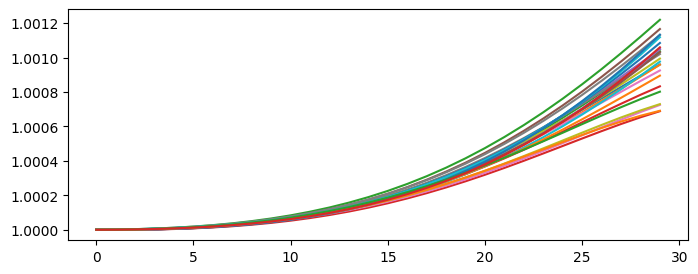

In [43]:
for i in range(len(sorted_fitness)):
    if sorted_fitness[i]:
        eq_fin = solve_order_6(jnp.array(sorted_population[i]), padded=False)
        fin_anisotropy = rms_anisotropy(eq_fin)
        fin_aspect = aspect_conv(eq_fin)
        fin_eps_conv = eps_conv(eq_fin)
        fin_iota = iota_axis(eq_fin)
        p20_avg = jnp.real(jnp.average(eq_fin.p_perp[2][0].content))
        p00_avg = jnp.real(jnp.average(eq_fin.p_perp[0][0].content))
        p_edge_eff = (p00_avg + p20_avg*eps**2)
        p_axis_eff = p00_avg
        print(
            'Δ:', f'{fin_anisotropy:>12.4e}', '    '
            'R/r:', f'{fin_aspect:>12.4e}', '    '
            'ι0:', f'{fin_iota:>12.4e}', '    '
            'p_axis-p_edge (estimate):', f'{p_axis_eff - p_edge_eff:>12.4e}', '    '
        )
        pres_profile = eq_fin.p_perp.eval_eps(jnp.linspace(0, fin_eps_conv, 30), 0, 0)
        plt.plot(pres_profile/jnp.max(pres_profile))
        if fin_anisotropy and fin_aspect and fin_iota:
            jnp.save('population_eq/eq'+str(i), eq_fin)

In [ ]:
eq_fin.unknown['B_psi_coef_cp'][1].content

In [ ]:
objective(sorted_population[i], 1., 1., 1., 1., 2)

# Optimization